### Load Libraries

In [1]:
from mofapy2.run.entry_point import entry_point
import pandas as pd
import numpy as np

ent = entry_point()


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




### Load Data

In [2]:
mrna_data = pd.read_csv("../../data/transformed_data/mofa_data/mrna_transformed_mofa.csv", index_col=0)
mirna_data = pd.read_csv("../../data/transformed_data/mofa_data/mirna_transformed_mofa.csv", index_col=0)
meth_data = pd.read_csv("../../data/transformed_data/mofa_data/meth_transformed_mofa.csv", index_col=0)

In [3]:
print('mRNA shape:', mrna_data.shape)
print('miRNA shape:', mirna_data.shape)
print('DNA methylation shape:', meth_data.shape)

mRNA shape: (177, 5000)
miRNA shape: (177, 500)
DNA methylation shape: (177, 10000)


### Create MOFA data matrix

1 group 3 views

In [4]:
data_mat = [[mrna_data.values], [mirna_data.values], [meth_data.values]]

### Define names for samples and features

In [5]:
views = ['mRNA', 'miRNA', 'dna_methylation']
samples = [mrna_data.index.tolist()]
features = [mrna_data.columns.tolist(), mirna_data.columns.tolist(), meth_data.columns.tolist()]

### Ensure the CpGs do not mathematically overpower the miRNAs

In [6]:
ent.set_data_options(scale_groups=False, scale_views=True)

Scaling views to unit variance...



Sanity Check

In [7]:
print("M (views):", len(data_mat))
print("G (groups):", len(data_mat[0]))
print("len(views):", len(views))
print("len(samples):", len(samples))
print("len(features):", len(features))

M (views): 3
G (groups): 1
len(views): 3
len(samples): 1
len(features): 3


### Load data into the model

since we applied log and M-value transformations, all likelihoods are Gaussian

In [8]:
ent.set_data_matrix(data_mat, likelihoods = ['gaussian', 'gaussian', 'gaussian'], views_names = views, groups_names = ['PAAD'], samples_names = samples, features_names = features)

Successfully loaded view='mRNA' group='PAAD' with N=177 samples and D=5000 features...
Successfully loaded view='miRNA' group='PAAD' with N=177 samples and D=500 features...
Successfully loaded view='dna_methylation' group='PAAD' with N=177 samples and D=10000 features...




### Set Model Options

- factors: number of factors
- spikeslab_weights: use spike-slab sparsity prior in weights? default is TRUE
- ard_weights: use ARD prior in the weights? Default is TRUE if using multiple views

In [9]:
ent.set_model_options(factors = 10, spikeslab_weights = True, ard_weights = True, ard_factors = True)

Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (mRNA): gaussian
- View 1 (miRNA): gaussian
- View 2 (dna_methylation): gaussian




### Set Training Options

- convergence_mode: 'fast' (default), 'medium', 'slow'
- dropR2: minimum variance explained criteria to drop factors while training
- gpu_mode: use GPU? (needs cupy installed and a functional GPU, see https://biofam.github.io/MOFA2/gpu_training.html)
- seed: random seed

In [10]:
ent.set_train_options(iter = 1000, convergence_mode = 'fast', startELBO = 1, freqELBO = 1, gpu_mode = False, seed = 1)

### Build and Train the MOFA model

In [11]:
ent.build()
ent.run()

#save the output
ent.save('../../data/transformed_data/mofa_data/mofa_paad_baseline.hdf5')



######################################
## Training the model with seed 1 ##
######################################


ELBO before training: -21268464.55 

Iteration 1: time=0.63, ELBO=-3415985.04, deltaELBO=17852479.509 (83.93873224%), Factors=10
Iteration 2: time=0.62, ELBO=-2809832.86, deltaELBO=606152.177 (2.85000441%), Factors=10
Iteration 3: time=0.63, ELBO=-2742419.40, deltaELBO=67413.468 (0.31696443%), Factors=10
Iteration 4: time=0.70, ELBO=-2717843.03, deltaELBO=24576.368 (0.11555309%), Factors=10
Iteration 5: time=0.81, ELBO=-2700551.48, deltaELBO=17291.549 (0.08130135%), Factors=10
Iteration 6: time=0.81, ELBO=-2688315.41, deltaELBO=12236.071 (0.05753152%), Factors=10
Iteration 7: time=0.94, ELBO=-2679502.41, deltaELBO=8813.000 (0.04143693%), Factors=10
Iteration 8: time=0.81, ELBO=-2673173.41, deltaELBO=6328.997 (0.02975766%), Factors=10
Iteration 9: time=1.00, ELBO=-2668628.94, deltaELBO=4544.475 (0.02136720%), Factors=10
Iteration 10: time=1.13, ELBO=-2665274.13, deltaEL

## Downstream Analysis

In [12]:
import mofax as mfx
import matplotlib.pyplot as plt

### Load the saved model into mofax

In [13]:
model = mfx.mofa_model('../../data/transformed_data/mofa_data/mofa_paad_baseline.hdf5')

### Plot Variance explained by each factor across three views

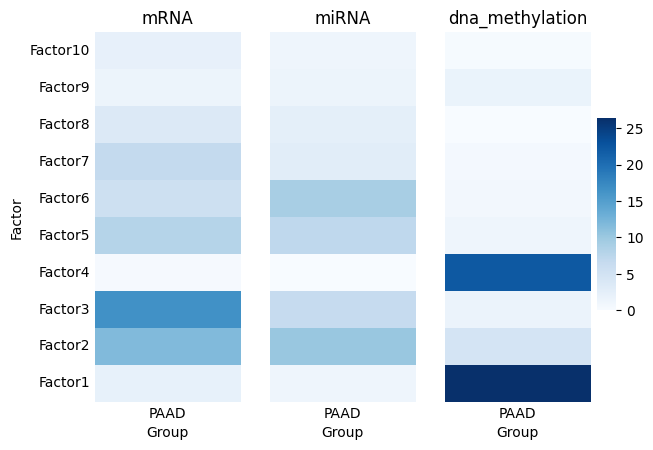

In [14]:
mfx.plot_r2(model, factors = (range(10)),cmap = 'Blues')

### Extract the Latent Factors (Z matrix)

In [15]:
factors_df = model.get_factors(df = True)

print(factors_df.head())

               Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
TCGA-HZ-A8P1  4.061125 -0.891145 -3.212838  1.079504 -0.061386 -1.004518   
TCGA-FB-AAPS -0.997797  0.833191  3.062827 -2.935918 -1.192113 -1.189249   
TCGA-IB-AAUN  2.513858 -1.807232 -0.309770 -3.847536  1.840057  0.393213   
TCGA-3A-A9I7 -1.677880  0.215408  1.350706  2.992675 -1.003911 -1.171167   
TCGA-FB-AAPY -0.324863 -0.719912  0.720676  2.434426  0.290757 -0.255733   

               Factor7   Factor8   Factor9  Factor10  
TCGA-HZ-A8P1 -2.455892  0.325954 -0.299391 -0.235193  
TCGA-FB-AAPS  1.376617 -0.372044 -0.263421  0.651219  
TCGA-IB-AAUN  0.630857 -0.019172 -0.406185 -0.207123  
TCGA-3A-A9I7 -1.130563  0.012304  0.134233  0.121180  
TCGA-FB-AAPY -0.384544  1.211493 -0.004491  0.086675  


### Tumor Subtype Classification using MOFA data

Load Libraries

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, average_precision_score

Load Clinical Data

In [17]:
clinical_data = pd.read_csv("../../data/transformed_data/mofa_data/clinical_transformed_mofa.csv", index_col='bcr_patient_barcode')

Keep Only target variable

In [18]:
target = clinical_data[['tumor_subtype']]

Sort target and factors_df dataframes

In [19]:
target = target.sort_values(by='bcr_patient_barcode')

In [20]:
factors_df = factors_df.sort_index()
factors_df.head(2)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
TCGA-2J-AAB1,4.729118,0.319167,0.039332,0.965862,0.516365,-0.534313,-1.839287,0.229708,-0.107279,0.231390
TCGA-2J-AAB4,-2.518252,-1.520752,0.384348,3.099006,1.432126,1.681916,-1.192181,0.480763,-0.164605,0.160029


Merge MOFA factors with target variable

In [21]:
merged_df = factors_df.join(target, how='inner')

Target (0 and 1)

In [22]:
merged_df['label'] = merged_df['tumor_subtype'].apply(lambda x: 1 if x == 'Ductal Type' else 0)

X = Factors; y = target

In [23]:
X = merged_df.drop(columns=['tumor_subtype', 'label'])
y = merged_df['label']

Stratified 5-Fold Cross Validation

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
f1_scores = []
pr_aucs = []

Training SVM on MOFA factors

In [26]:
for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    classifier = SVC(kernel = 'rbf', class_weight = 'balanced', probability = True, random_state = 42)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)
    y_prob = classifier.predict_proba(X_test)[:, 1]
  
    fold_f1 = f1_score(y_test, y_pred)
    fold_pr_auc = average_precision_score(y_test, y_prob)

    f1_scores.append(fold_f1)
    pr_aucs.append(fold_pr_auc)

    print(f"Fold {fold} - F1 Score: {fold_f1:.3f} | PR AUC: {fold_pr_auc:.3f}")

print(f'Average F1-Score: {sum(f1_scores)/len(f1_scores):.3f}')
print(f'Average PR AUC: {sum(pr_aucs)/len(pr_aucs):.3f}')

Fold 1 - F1 Score: 0.755 | PR AUC: 0.935
Fold 2 - F1 Score: 0.786 | PR AUC: 0.828
Fold 3 - F1 Score: 0.857 | PR AUC: 0.959
Fold 4 - F1 Score: 0.833 | PR AUC: 0.822
Fold 5 - F1 Score: 0.857 | PR AUC: 0.962
Average F1-Score: 0.818
Average PR AUC: 0.901


## Biomarker Discovery